In [1]:
#Change these directory filepaths

#Filepath for directory where the data is stored
data_dir = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\AVRF_group\\group_paper\\'

#Filepath for where you want the figures to be saved
save_plot_dir = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\AVRF_group\\group_paper\\figures\\'

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
import matplotlib.dates as mdates


In [3]:
#Things for plotting
colordict = {'control': "#7F7F7F",
             'below':  "#008000",
             'east': "#DAA520",
             'west': "#87CEEB",
             'south': "#215F9A",
             'other1': "#FF0000",
             'other2': "#C04F15",
             'other3': "#800080"
             }

arraycolor = colordict['other2'] #Color to represent whole array

hh_index = np.arange(0, 24, 0.5)
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)

## Functions

In [4]:
#Function for reading in and formatting data
def rnf(filepath): # function for reading and formatting dataframes from csv-like file
    df = pd.read_csv(filepath, header = [0]) #read in file
    df['dt_ts'] = pd.to_datetime(df['dt_ts'], format = '%Y-%m-%d %H:%M:%S')
    
    df.set_index('dt_ts', inplace = True) #Set dt_ts as index

    return df

### Averaging functions

In [5]:
#functions for averaging data - diel cycle and 1 day average, day average can also be used with different frequency input as avg_time
def day_cyc(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf')):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.groupby(data.index.time).mean()
    return avg 

#Take 7-day average where each half hour of day is weighted evenly (average across days, then across times)
def weighted_week_avg(data, sd = 0, ed = 0, avg_time = '7d'):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
   
    week_avg = data.groupby([pd.Grouper(freq=avg_time), data.index.time]).mean().groupby(level=0).mean()
    week_avg.index = week_avg.index + pd.Timedelta('3.5D')
    return week_avg

## Read in and Process Data

In [6]:
KSA_use = rnf(data_dir + 'KSA.csv')
KSC_use = rnf(data_dir + 'KSC.csv')


# Plots

### NEE and ET

Make NEE positive and change untis? #fixthis

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_16548\3493612828.py:4: SyntaxWarning: invalid escape sequence '\ '
  vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
C:\Users\emily\AppData\Local\Temp\ipykernel_16548\3493612828.py:5: SyntaxWarning: invalid escape sequence '\ '
  'ET': '[$mm \ d^-1$]',


NEE
ET


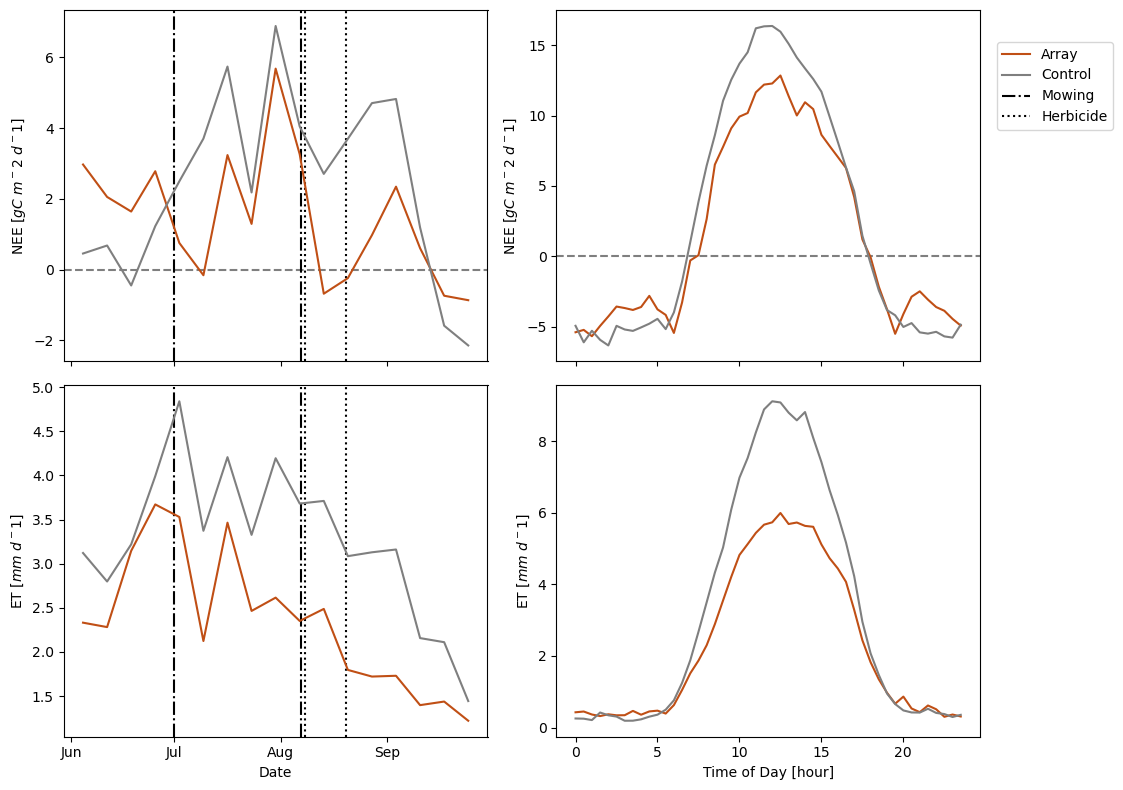

In [7]:
#Flux plots (NEE and ET)

#Dictionary with variable names and units
vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
           'ET': '[$mm \ d^-1$]',
}

#Create plot
figsize = (10, 8)
fig, axs = plt.subplots(2,2,  figsize = figsize, sharex = 'col')

#Add zero line for NEE plots
for ax in axs[0, :]:
    ax.axhline(0, c = 'k', linestyle = '--', alpha = 0.5) #first mowing


#Add management as vertical lines on each plot
for ax in axs[:, 0]:
    # m1 = ax.axvspan(xmin=dt.datetime(2025, 7, 1), xmax=dt.datetime(2025, 7, 3), alpha=0.3, color=colordict['below'])
    # ax.axvspan(xmin=dt.datetime(2025, 8, 4), xmax=dt.datetime(2025, 8, 8), alpha=0.3, color=colordict['below'])
    # m2 = ax.axvspan(xmin=dt.datetime(2025, 8, 8), xmax=dt.datetime(2025, 8, 9), alpha=0.3, color=colordict['other3'])
    m1 = ax.axvline(dt.datetime(2025, 7, 1), color = 'k',linestyle = '-.')
    ax.axvline(dt.datetime(2025, 8, 7), color='k', linestyle = '-.')
    m2 = ax.axvline(dt.datetime(2025, 8, 8), color = 'k',linestyle = ':')
    ax.axvline(dt.datetime(2025, 8, 20), color = 'k',linestyle = ':')


#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(len(vardict.keys())): #Need i for plotting
    var = list(vardict.keys())[i]
    units = vardict[var]
    print(var)

    #Time series plot
    #Select left axis
    axl = axs[i, 0]

    KSA_avg = weighted_week_avg(KSA_use[var])
    KSC_avg = weighted_week_avg(KSC_use[var])
    
    #Plot time series on left axis
    l1 = axl.plot(KSA_avg[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSC_avg[sd:ed], label = 'Control', c = colordict['control'])

    axl.set_ylabel(var  + ' ' + units)

    #Cumulative plot
    #Right axis
    axr = axs[i, 1]

    #calculate cumulative values
    KSA_day_cyc = day_cyc(KSA_use[var])
    KSC_day_cyc = day_cyc(KSC_use[var])

    axr.set_ylabel(var  + ' ' + units)
    

    axr.plot(hh_index, KSA_day_cyc, c = arraycolor)
    axr.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], m1, m2]


axl.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axl.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

#X-axis labels
axl.set_xlabel('Date')
axr.set_xlabel('Time of Day [hour]')

#Add figure legend
fig.legend(handles, ['Array', 'Control', 'Mowing', 'Herbicide'], loc = 'upper right', bbox_to_anchor=(1.125, .95))

#Save figure
fig.tight_layout()
plt.savefig(save_plot_dir + 'NEE_and_ET_plots.png', bbox_inches='tight')

### Energy Balance

In [8]:
#Create dataframe with weekly average estimated power output
array_area = 6.5e5 #m^2 (6.5 ha)
dtindex_1d = pd.date_range(start = sd, end = ed, freq = '1D') #datetime index with frequency of 1 day
PO_1d = pd.DataFrame(index = dtindex_1d, columns = ['KSA', 'KSC']) #Dataframe with estimated power output, 1 val/day

#Approximate DC power production by array (using PVwatts from NREL)
PO_month = np.array([404/30, 425/31, 419/31, 379/30, 335/31]) #Array of estimated power output divided by days in month for June - October [KWh/day]
PO_month*1e3/24/array_area #[W/m^2] Average rate of energy removed from array for power production


# Adds average power output for each day to the PO_1d dataframe
month_map = {i+6: val for i, val in enumerate(PO_month)} #dictionary of month value: power output value
PO_1d['KSA'] = PO_1d.index.month.map(month_map) #Uses month_map to fill in power_output column of PO_1d
PO_1d['KSC'] = 0
PO_1w = weighted_week_avg(PO_1d)[sd:ed] #resamples to 1 week, timestamp is middle of week


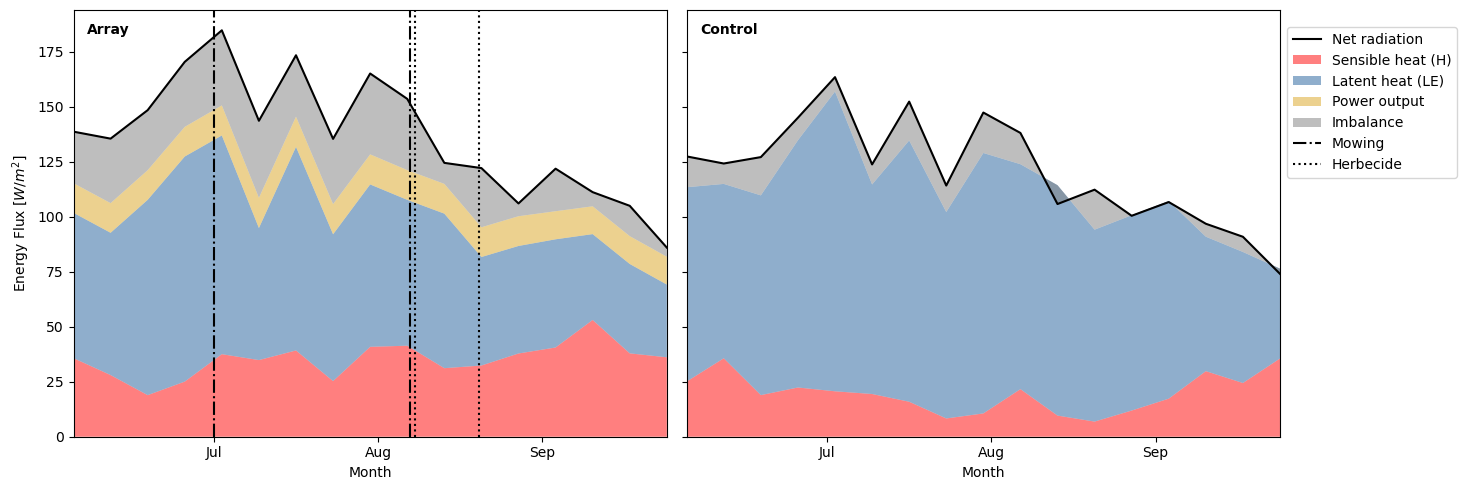

In [9]:
fig, axs = plt.subplots(1, 2, figsize = (13, 5), sharey = 'row')

#Dictionary of tower data
towdat_dict = {'KSA': KSA_use, 'KSC': KSC_use}

for i in range(len(axs)):
    ax = axs[i] #select axes
    tow = list(towdat_dict.keys())[i] #select tower
    towdat = towdat_dict[tow] #select data for given tower

    #Calculated values
    towdat_1w = weighted_week_avg(towdat)[sd:ed] #Take one week average of towdat. Date index is center of average week
    RN = towdat_1w['SWin'] + towdat_1w['LWin'] - towdat_1w['SWout'] - towdat_1w['LWout'] #Calculation net radiation

    #Plots
    l1 = ax.plot(RN, c = 'k', label = 'Net radiation') #Plot net radiation as a line
    #Stacked plot of outgoing energy fluxes (H, LE, power output for array, and energy imbalance)
    sp = ax.stackplot(towdat_1w.index, towdat_1w['H'], towdat_1w['LE'], PO_1w[tow], RN - towdat_1w['H'] - towdat_1w['LE'] - PO_1w[tow],
                 labels = ['Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance'],
                 colors = [colordict['other1'], colordict['south'],colordict['east'], colordict['control']], alpha = 0.5) 
    
    #Format x axis
    ax.set_xlim(towdat_1w.index.min(), towdat_1w.index.max())
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name
    ax.set_xlabel('Month')

#Add management as vertical lines
m1 = axs[0].axvline(dt.datetime(2025, 7, 1), color = 'k',linestyle = '-.', label = 'mowing')
axs[0].axvline(dt.datetime(2025, 8, 7), color='k', linestyle = '-.')
m2 = axs[0].axvline(dt.datetime(2025, 8, 8), color = 'k',linestyle = ':', label = 'herbecide')
axs[0].axvline(dt.datetime(2025, 8, 20), color = 'k',linestyle = ':')


#Shared y axis
axs[0].set_ylabel('Energy Flux [$W/m^2$]')

#Add tower names to each panell
axs[0].annotate('Array', (sd + dt.timedelta(days = 6), 183), weight = 'bold')
axs[1].annotate('Control', (sd + dt.timedelta(days = 6), 183), weight = 'bold')

#Add figure legend 
handles = [l1[0], sp[0], sp[1], sp[2], sp[3], m1, m2]
fig.legend(handles, ['Net radiation', 'Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance', 'Mowing', 'Herbecide'], 
           loc = 'upper right', bbox_to_anchor=(1.13, .95)) #fixthis

plt.tight_layout()

plt.savefig(save_plot_dir + 'Energy_balance_plots.png', bbox_inches='tight')


### TA and RH

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
C:\Users\emily\AppData\Local\Temp\ipykernel_16548\3199619361.py:4: SyntaxWarning: invalid escape sequence '\c'
  vardict = {'$T_{air}$': ['TA1', 'TA2', '[$^\circ$C]'],
C:\Users\emily\AppData\Local\Temp\ipykernel_16548\3199619361.py:92: SyntaxWarning: invalid escape sequence '\D'
  fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$ (array 2, control)'], bbox_to_anchor=(.88, 1.05), ncol=len(handles))
C:\Users\emily\AppData\Local\Temp\ipykernel_16548\3199619361.py:92: SyntaxWarning: invalid escape sequence '\D'
  fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$

$T_{air}$
RH


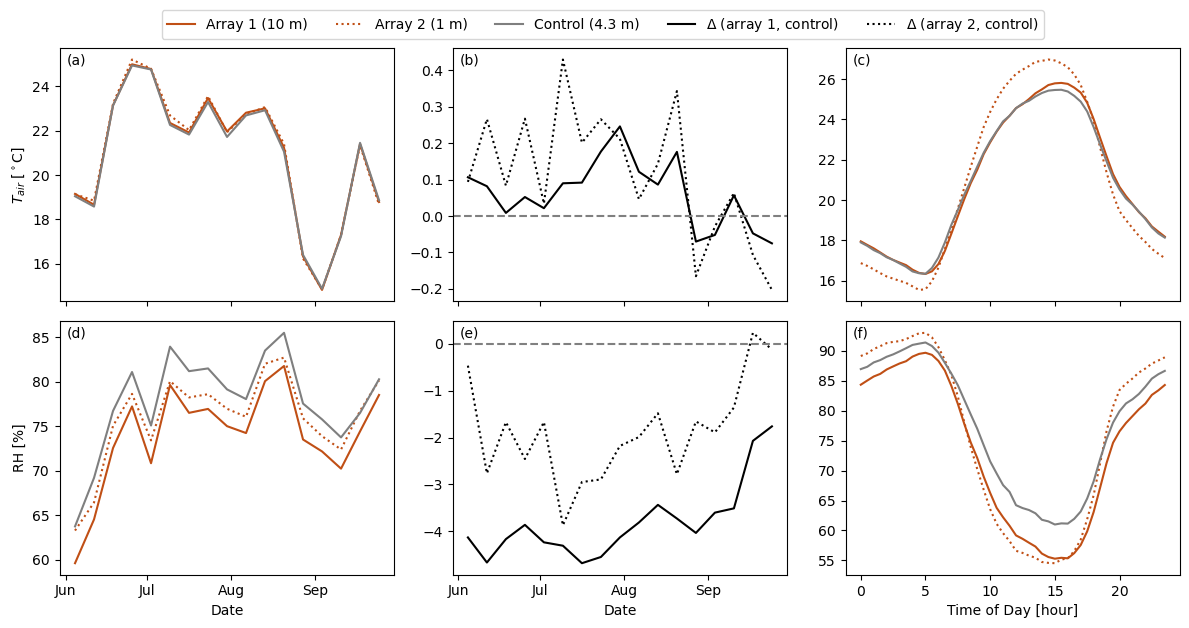

In [11]:
#Micromet - TA and RH plot

#Dictionary with variable names and units
vardict = {'$T_{air}$': ['TA1', 'TA2', '[$^\circ$C]'],
           'RH': ['RH1', 'RH2', '[%]']
}

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

#Create plot
figsize = (12, 6)
fig, axs = plt.subplots(2,3,  figsize = figsize, sharex = 'col')



#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(len(vardict.keys())): #Need i for plotting
    var = list(vardict.keys())[i]
    col1 = vardict[var][0]
    col2 = vardict[var][1]
    units = vardict[var][2]
    print(var)

    #Time series plot
    #Select left axis
    axl = axs[i, 0]

    KSA_avg1 = weighted_week_avg(KSA_use[col1])
    KSA_avg2 = weighted_week_avg(KSA_use[col2])
    KSC_avg = weighted_week_avg(KSC_use[col1])
    
    #Plot time series on left axis
    l1 = axl.plot(KSA_avg1[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSA_avg2[sd:ed], label = 'Array', c = arraycolor, linestyle = ':')
    l3 = axl.plot(KSC_avg[sd:ed], label = 'Control', c = colordict['control'])

    axl.set_ylabel(var  + ' ' + units)

    
    #Difference plot
    #select center axis
    axc = axs[i, 1]

    KSA_avg1 = weighted_week_avg(KSA_use[col1])
    KSA_avg2 = weighted_week_avg(KSA_use[col2])
    KSC_avg = weighted_week_avg(KSC_use[col1])
    
    #Plot time series on left axis
    l4 = axc.plot(KSA_avg1[sd:ed] - KSC_avg[sd:ed], label = 'Array', c = 'k')
    l5 = axc.plot(KSA_avg2[sd:ed] - KSC_avg[sd:ed], label = 'Array', c = 'k', linestyle = ':')
    axc.axhline(0, linestyle = '--', c= 'gray')

    axl.set_ylabel(var  + ' ' + units)

    #Cumulative plot
    #Right axis
    axr = axs[i, 2]

    #calculate cumulative values
    KSA_day_cyc1 = day_cyc(KSA_use[col1])
    KSA_day_cyc2 = day_cyc(KSA_use[col2])
    KSC_day_cyc = day_cyc(KSC_use[col1])

    # axr.set_ylabel(var  + ' ' + units)
    

    axr.plot(hh_index, KSA_day_cyc1, c = arraycolor)
    axr.plot(hh_index, KSA_day_cyc2, c = arraycolor, linestyle = ':')
    axr.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], l3[0], l4[0], l5[0]]

for j in range(len(axs.flatten())):
    ax = axs.flatten()[j]
    ax.annotate(labels[j], (.02, .935), xycoords = 'axes fraction')

#Set x axes labels as month names
axl.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axl.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name
axc.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axc.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

#X-axis labels
axl.set_xlabel('Date')
axc.set_xlabel('Date')
axr.set_xlabel('Time of Day [hour]')

#Add figure legend
fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$ (array 2, control)'], bbox_to_anchor=(.88, 1.05), ncol=len(handles))

#Save figure
save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')